In [1]:
import sys, json, time, math, random
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from pitchpulse.contract import from_record, find_player
from pitchpulse.scorer import get_scorer
from pitchpulse.simulate import (
    what_if, move_to, optimise_player, joint_optimise, heatmap_sweep
)

random.seed(42)
GOAL = (120.0, 40.0)

scorer = get_scorer()
print("scorer:", scorer.name, "| trained model:", scorer.is_trained_model)

[scorer] using HeuristicScorer -- PLACEHOLDER, not a trained model. Do not report accuracy figures produced with this.
scorer: heuristic-placeholder | trained model: False


In [2]:
def load(path, freekick=False):
    rows = [json.loads(l) for l in open(path)]
    if freekick:
        rows = [r for r in rows if r.get("set_piece_type") == "freekick_delivery"]
    rows = [r for r in rows if r["has_freeze_frame"]]
    return [s for s in (from_record(r) for r in rows) if s]

corners   = load("output/corners_dataset_full.jsonl")
freekicks = load("output/freekicks_dataset_full.jsonl", freekick=True)

DATASETS = {"Corners": corners, "Free kicks": freekicks}

for name, data in DATASETS.items():
    scores = [scorer(s) for s in data[:300]]
    print(f"{name:<12} {len(data):>5} scenarios | "
          f"players/frame {sum(len(s['players']) for s in data)/len(data):.1f} | "
          f"score {min(scores):.3f}-{max(scores):.3f}")

Corners       2468 scenarios | players/frame 18.6 | score 0.068-0.190
Free kicks    1090 scenarios | players/frame 19.4 | score 0.084-0.256


In [3]:
demo = freekicks[0]
attackers = [p for p in demo["players"] if p["teammate"] and not p["actor"]]
target = min(attackers, key=lambda p: math.hypot(p["x"]-GOAL[0], p["y"]-GOAL[1]))

print(f"scenario: {demo['set_piece_type']} | {len(demo['players'])} players")
print(f"target player {target['id']} at [{target['x']:.1f}, {target['y']:.1f}]")
print(f"baseline Danger Score: {scorer(demo):.3f}\n")

for dx, dy, label in [(5,0,"toward goal"), (-5,0,"away from goal"),
                      (0,5,"wide left"), (0,-5,"wide right")]:
    r = what_if(demo, target["id"], target["x"]+dx, target["y"]+dy, scorer)
    print(f"  {label:<16} {r['score_before']:.3f} -> {r['score_after']:.3f}   "
          f"delta {r['delta']:+.3f}   clamped: {r['was_clamped']}")

scenario: freekick | 20 players
target player 14 at [109.2, 42.9]
baseline Danger Score: 0.211

  toward goal      0.211 -> 0.221   delta +0.010   clamped: False
  away from goal   0.211 -> 0.208   delta -0.003   clamped: False
  wide left        0.211 -> 0.209   delta -0.002   clamped: False
  wide right       0.211 -> 0.215   delta +0.004   clamped: False


In [4]:
demo_c = corners[0]
attackers_c = [p for p in demo_c["players"] if p["teammate"] and not p["actor"]]
target_c = min(attackers_c, key=lambda p: math.hypot(p["x"]-GOAL[0], p["y"]-GOAL[1]))

print(f"scenario: {demo_c['set_piece_type']} | {len(demo_c['players'])} players")
print(f"target player {target_c['id']} at [{target_c['x']:.1f}, {target_c['y']:.1f}]")
print(f"baseline Danger Score: {scorer(demo_c):.3f}\n")

for dx, dy, label in [(5,0,"toward goal"), (-5,0,"away from goal"),
                      (0,5,"wide left"), (0,-5,"wide right")]:
    r = what_if(demo_c, target_c["id"], target_c["x"]+dx, target_c["y"]+dy, scorer)
    print(f"  {label:<16} {r['score_before']:.3f} -> {r['score_after']:.3f}   "
          f"delta {r['delta']:+.3f}   clamped: {r['was_clamped']}")

scenario: corner | 20 players
target player 17 at [117.4, 39.9]
baseline Danger Score: 0.138

  toward goal      0.138 -> 0.142   delta +0.004   clamped: True
  away from goal   0.138 -> 0.133   delta -0.005   clamped: False
  wide left        0.138 -> 0.138   delta -0.000   clamped: False
  wide right       0.138 -> 0.134   delta -0.004   clamped: False


evaluated 81 candidates in 16 ms
  original : [109.2, 42.9]
  best     : [114.2, 42.9]
  score    : 0.211 -> 0.221


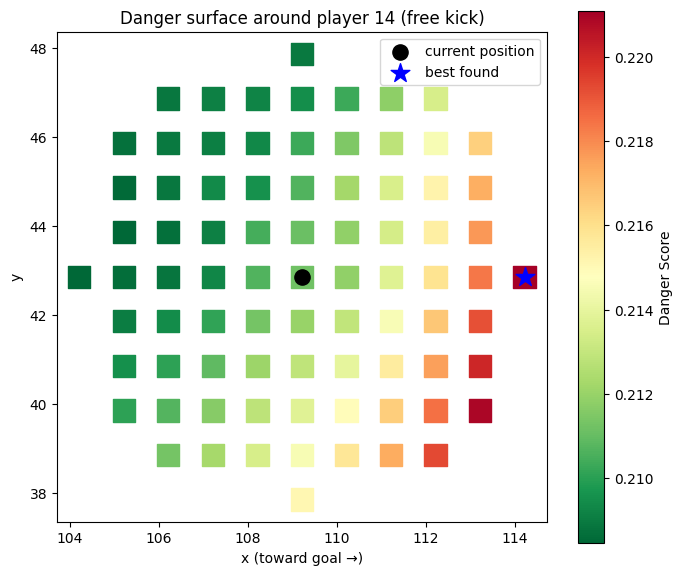

In [5]:
t0 = time.perf_counter()
opt = optimise_player(demo, target["id"], scorer, maximise=True)
elapsed = (time.perf_counter() - t0) * 1000

print(f"evaluated {opt['candidates_evaluated']} candidates in {elapsed:.0f} ms")
print(f"  original : [{opt['original_position'][0]:.1f}, {opt['original_position'][1]:.1f}]")
print(f"  best     : [{opt['best_position'][0]:.1f}, {opt['best_position'][1]:.1f}]")
print(f"  score    : {opt['baseline_score']:.3f} -> {opt['best_score']:.3f}")

hm = heatmap_sweep(demo, target["id"], scorer)
xs = [c["x"] for c in hm["cells"]]
ys = [c["y"] for c in hm["cells"]]
vs = [c["score"] for c in hm["cells"]]

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(xs, ys, c=vs, s=260, cmap="RdYlGn_r", marker="s")
ax.scatter(*hm["origin"], c="black", s=120, marker="o", label="current position")
ax.scatter(*opt["best_position"], c="blue", s=200, marker="*", label="best found")
plt.colorbar(sc, label="Danger Score")
ax.set_xlabel("x (toward goal →)"); ax.set_ylabel("y")
ax.set_title(f"Danger surface around player {target['id']} (free kick)")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

evaluated 81 candidates in 14 ms
  original : [117.4, 39.9]
  best     : [119.9, 39.9]
  score    : 0.138 -> 0.142


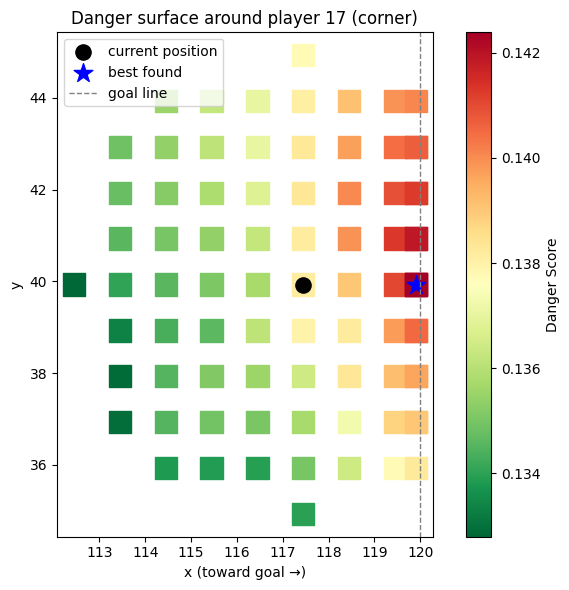

In [6]:
t0 = time.perf_counter()
opt_c = optimise_player(demo_c, target_c["id"], scorer, maximise=True)
elapsed_c = (time.perf_counter() - t0) * 1000

print(f"evaluated {opt_c['candidates_evaluated']} candidates in {elapsed_c:.0f} ms")
print(f"  original : [{opt_c['original_position'][0]:.1f}, {opt_c['original_position'][1]:.1f}]")
print(f"  best     : [{opt_c['best_position'][0]:.1f}, {opt_c['best_position'][1]:.1f}]")
print(f"  score    : {opt_c['baseline_score']:.3f} -> {opt_c['best_score']:.3f}")

hm_c = heatmap_sweep(demo_c, target_c["id"], scorer)
xs = [c["x"] for c in hm_c["cells"]]
ys = [c["y"] for c in hm_c["cells"]]
vs = [c["score"] for c in hm_c["cells"]]

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(xs, ys, c=vs, s=260, cmap="RdYlGn_r", marker="s")
ax.scatter(*hm_c["origin"], c="black", s=120, marker="o", label="current position")
ax.scatter(*opt_c["best_position"], c="blue", s=200, marker="*", label="best found")
ax.axvline(120, color="grey", ls="--", lw=1, label="goal line")
plt.colorbar(sc, label="Danger Score")
ax.set_xlabel("x (toward goal →)"); ax.set_ylabel("y")
ax.set_title(f"Danger surface around player {target_c['id']} (corner)")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [7]:
for label, scen in [("Free kick", demo), ("Corner", demo_c)]:
    atts = [p for p in scen["players"] if p["teammate"] and not p["actor"]]
    ids = [p["id"] for p in atts[:3]]

    single_best = max(
        optimise_player(scen, i, scorer, maximise=True)["best_score"] for i in ids
    )

    t0 = time.perf_counter()
    joint = joint_optimise(scen, ids, scorer, maximise=True, rounds=2)
    ms = (time.perf_counter() - t0) * 1000

    print(f"--- {label} ---")
    print(f"  baseline          : {joint['baseline_score']:.3f}")
    print(f"  best single player: {single_best:.3f}")
    print(f"  joint (3 players) : {joint['final_score']:.3f}  (+{joint['improvement']:.3f})")
    print(f"  {len(joint['history'])} moves in {ms:.0f} ms\n")

--- Free kick ---
  baseline          : 0.211
  best single player: 0.215
  joint (3 players) : 0.234  (+0.022)
  6 moves in 81 ms

--- Corner ---
  baseline          : 0.138
  best single player: 0.143
  joint (3 players) : 0.155  (+0.017)
  6 moves in 80 ms



In [8]:
for name, data in DATASETS.items():
    sample = data[:300]

    t0 = time.perf_counter()
    for s in sample:
        scorer(s)
    per_score = (time.perf_counter() - t0) / len(sample) * 1000

    s0 = data[0]
    p0 = [p for p in s0["players"] if p["teammate"] and not p["actor"]][0]

    t0 = time.perf_counter()
    for _ in range(100):
        what_if(s0, p0["id"], p0["x"]+2, p0["y"]+2, scorer)
    per_edit = (time.perf_counter() - t0) / 100 * 1000

    t0 = time.perf_counter()
    optimise_player(s0, p0["id"], scorer, maximise=True)
    per_opt = (time.perf_counter() - t0) * 1000

    print(f"{name}")
    print(f"  single score            : {per_score:.2f} ms")
    print(f"  what-if edit (rebuild)  : {per_edit:.2f} ms")
    print(f"  81-candidate search     : {per_opt:.0f} ms\n")

Corners
  single score            : 0.05 ms
  what-if edit (rebuild)  : 0.21 ms
  81-candidate search     : 13 ms

Free kicks
  single score            : 0.05 ms
  what-if edit (rebuild)  : 0.21 ms
  81-candidate search     : 14 ms



In [9]:
def defensive_directional_agreement(scenarios, scorer, n=300):
    agree = total = 0
    for s in scenarios[:n]:
        defs = [p for p in s["players"] if not p["teammate"] and not p["keeper"]]
        atts = [p for p in s["players"] if p["teammate"] and not p["actor"]]
        if not defs or not atts:
            continue
        d = random.choice(defs)
        a = min(atts, key=lambda a: math.hypot(a["x"]-d["x"], a["y"]-d["y"]))
        total += 1
        agree += what_if(s, d["id"], a["x"], a["y"], scorer)["delta"] < 0
    return agree / total, total


def attacking_improvement_rate(scenarios, scorer, n=150):
    found = total = 0
    gains = []
    for s in scenarios[:n]:
        atts = [p for p in s["players"] if p["teammate"] and not p["actor"]]
        if not atts:
            continue
        total += 1
        r = optimise_player(s, random.choice(atts)["id"], scorer, maximise=True)
        found += r["improvement_found"]
        gains.append(r["improvement"])
    return found / total, sum(gains) / len(gains), total


RESULTS = {}
for name, data in DATASETS.items():
    d_rate, d_n = defensive_directional_agreement(data, scorer)
    a_rate, a_gain, a_n = attacking_improvement_rate(data, scorer)
    RESULTS[name] = {"dir": d_rate, "imp": a_rate, "gain": a_gain}
    print(f"{name}")
    print(f"  defensive directional agreement : {d_rate:.1%}  (n={d_n})")
    print(f"  attacking improvement found     : {a_rate:.1%}  (n={a_n})")
    print(f"  mean gain when improving        : {a_gain:+.4f}\n")

Corners
  defensive directional agreement : 84.3%  (n=300)
  attacking improvement found     : 100.0%  (n=150)
  mean gain when improving        : +0.0039

Free kicks
  defensive directional agreement : 88.3%  (n=300)
  attacking improvement found     : 100.0%  (n=150)
  mean gain when improving        : +0.0037



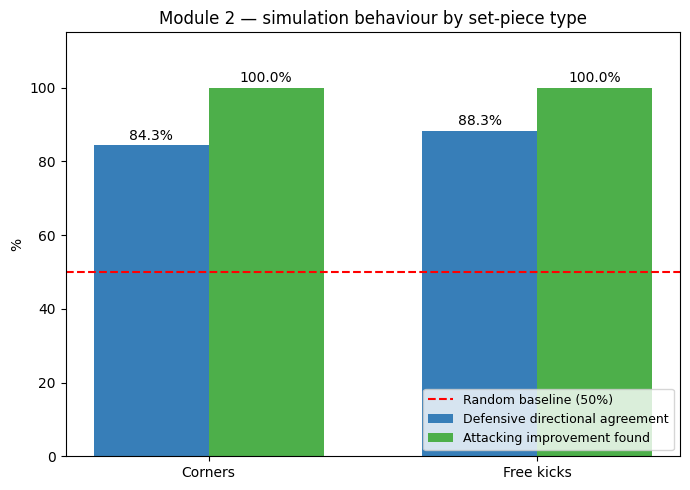

In [10]:
labels = list(RESULTS.keys())
dir_vals = [RESULTS[k]["dir"]*100 for k in labels]
imp_vals = [RESULTS[k]["imp"]*100 for k in labels]

x = range(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar([i-w/2 for i in x], dir_vals, w, label="Defensive directional agreement", color="#377eb8")
b2 = ax.bar([i+w/2 for i in x], imp_vals, w, label="Attacking improvement found", color="#4daf4a")
ax.axhline(50, color="red", ls="--", lw=1.5, label="Random baseline (50%)")

for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.5,
            f"{b.get_height():.1f}%", ha="center", fontsize=10)

ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("%"); ax.set_ylim(0, 115)
ax.set_title("Module 2 — simulation behaviour by set-piece type")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

In [11]:
def strategy_random(scen, pid, scorer):
    ang = random.uniform(0, 2*math.pi)
    p = find_player(scen, pid)
    return what_if(scen, pid, p["x"]+5*math.cos(ang), p["y"]+5*math.sin(ang), scorer)["delta"]

def strategy_greedy(scen, pid, scorer):
    p = find_player(scen, pid)
    dx, dy = GOAL[0]-p["x"], GOAL[1]-p["y"]
    d = math.hypot(dx, dy) or 1.0
    return what_if(scen, pid, p["x"]+5*dx/d, p["y"]+5*dy/d, scorer)["delta"]

def strategy_search(scen, pid, scorer):
    r = optimise_player(scen, pid, scorer, maximise=True)
    return r["best_score"] - r["baseline_score"]

STRATEGIES = {"Random": strategy_random,
              "Naive greedy": strategy_greedy,
              "Grid search (ours)": strategy_search}

BASELINE = {}
for name, data in DATASETS.items():
    BASELINE[name] = {}
    print(f"--- {name} ---")
    for sname, fn in STRATEGIES.items():
        random.seed(42)
        gains = []
        for s in data[:150]:
            atts = [p for p in s["players"] if p["teammate"] and not p["actor"]]
            if not atts:
                continue
            gains.append(fn(s, random.choice(atts)["id"], scorer))
        mean = sum(gains)/len(gains)
        pos = sum(1 for g in gains if g > 0)/len(gains)
        BASELINE[name][sname] = mean
        print(f"  {sname:<20} mean {mean:+.4f}   improved {pos:.0%}   (n={len(gains)})")
    print()

--- Corners ---
  Random               mean +0.0005   improved 53%   (n=150)
  Naive greedy         mean +0.0036   improved 100%   (n=150)
  Grid search (ours)   mean +0.0037   improved 100%   (n=150)

--- Free kicks ---
  Random               mean +0.0006   improved 55%   (n=150)
  Naive greedy         mean +0.0034   improved 100%   (n=150)
  Grid search (ours)   mean +0.0034   improved 100%   (n=150)



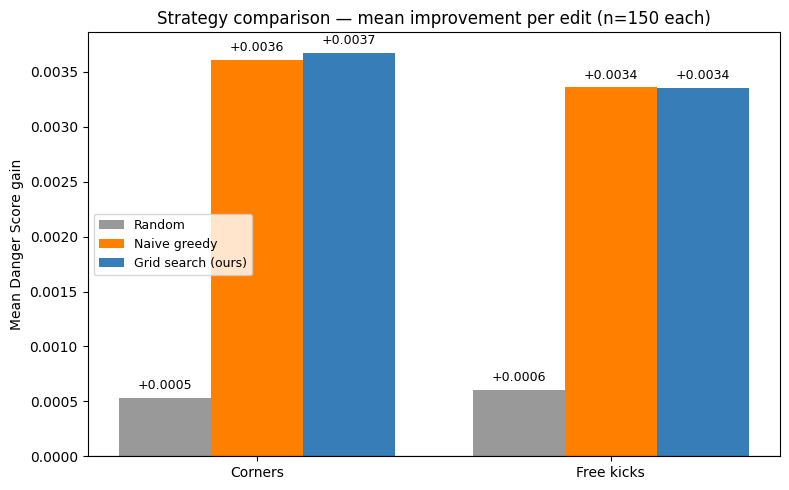

In [12]:
strats = list(STRATEGIES.keys())
labels = list(BASELINE.keys())
colors = ["#999999", "#ff7f00", "#377eb8"]

x = range(len(labels))
w = 0.26

fig, ax = plt.subplots(figsize=(8, 5))
for i, (sname, col) in enumerate(zip(strats, colors)):
    vals = [BASELINE[l][sname] for l in labels]
    bars = ax.bar([p + (i-1)*w for p in x], vals, w, label=sname, color=col)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.00008,
                f"{b.get_height():+.4f}", ha="center", fontsize=9)

ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("Mean Danger Score gain")
ax.set_title("Strategy comparison — mean improvement per edit (n=150 each)")
ax.legend(fontsize=9)
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

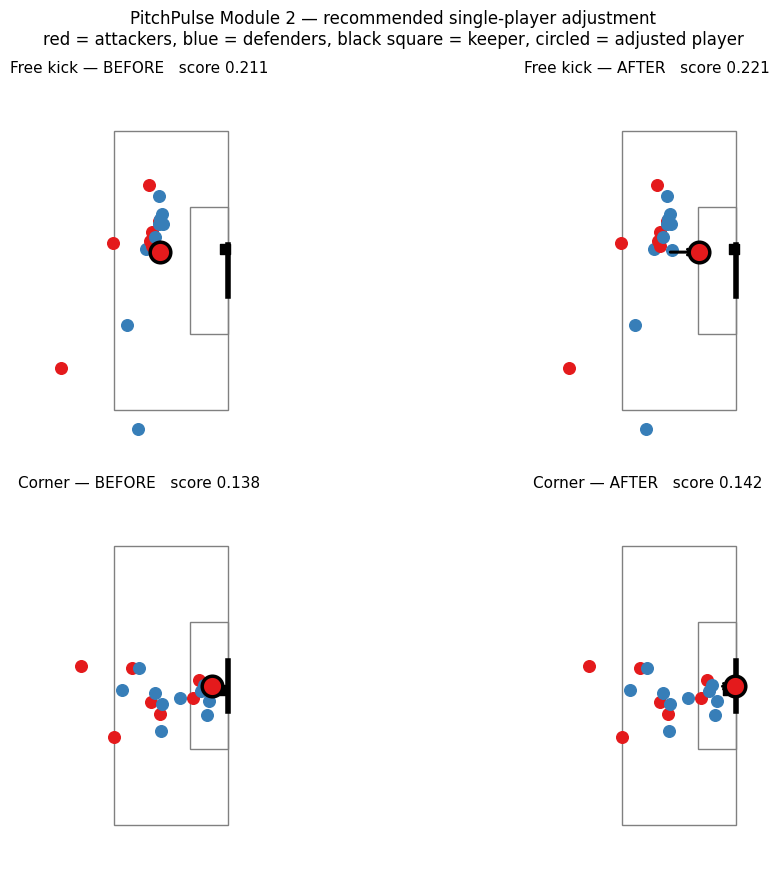

In [13]:
def draw_pitch(ax, scen, title, moved_id=None, from_pos=None):
    ax.add_patch(plt.Rectangle((102, 18), 18, 44, fill=False, color="grey", lw=1))
    ax.add_patch(plt.Rectangle((114, 30), 6, 20, fill=False, color="grey", lw=1))
    ax.plot([120, 120], [36, 44], color="black", lw=4)

    for p in scen["players"]:
        if p["keeper"]:
            c, m, s = "black", "s", 60
        elif p["teammate"]:
            c, m, s = "#e41a1c", "o", 70
        else:
            c, m, s = "#377eb8", "o", 70
        if p["id"] == moved_id:
            ax.scatter(p["x"], p["y"], c=c, s=220, marker=m,
                       edgecolors="black", linewidths=2.5, zorder=5)
        else:
            ax.scatter(p["x"], p["y"], c=c, s=s, marker=m, zorder=3)

    if from_pos is not None:
        p = find_player(scen, moved_id)
        ax.annotate("", xy=(p["x"], p["y"]), xytext=from_pos,
                    arrowprops=dict(arrowstyle="->", lw=2.2, color="black"))

    ax.set_xlim(88, 124); ax.set_ylim(10, 70)
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal"); ax.axis("off")


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

draw_pitch(axes[0][0], demo, f"Free kick — BEFORE   score {scorer(demo):.3f}",
           moved_id=target["id"])
draw_pitch(axes[0][1], opt["scenario"], f"Free kick — AFTER   score {opt['best_score']:.3f}",
           moved_id=target["id"], from_pos=opt["original_position"])

draw_pitch(axes[1][0], demo_c, f"Corner — BEFORE   score {scorer(demo_c):.3f}",
           moved_id=target_c["id"])
draw_pitch(axes[1][1], opt_c["scenario"], f"Corner — AFTER   score {opt_c['best_score']:.3f}",
           moved_id=target_c["id"], from_pos=opt_c["original_position"])

fig.suptitle("PitchPulse Module 2 — recommended single-player adjustment\n"
             "red = attackers, blue = defenders, black square = keeper, "
             "circled = adjusted player", fontsize=12)
plt.tight_layout(); plt.show()

In [14]:
line = "=" * 62
print(line)
print("PitchPulse Module 2 — Evaluation Summary")
print(f"scorer: {scorer.name}   trained model: {scorer.is_trained_model}")
print(line)

print(f"\n{'DATASET':<26}{'Corners':>16}{'Free kicks':>18}")
print(f"{'scenarios':<26}{len(corners):>16}{len(freekicks):>18}")
print(f"{'mean players / frame':<26}"
      f"{sum(len(s['players']) for s in corners)/len(corners):>16.1f}"
      f"{sum(len(s['players']) for s in freekicks)/len(freekicks):>18.1f}")

print(f"\n{'SIMULATION BEHAVIOUR':<26}{'Corners':>16}{'Free kicks':>18}")
print(f"{'directional agreement':<26}"
      f"{RESULTS['Corners']['dir']:>15.1%}{RESULTS['Free kicks']['dir']:>18.1%}")
print(f"{'improvement found':<26}"
      f"{RESULTS['Corners']['imp']:>15.1%}{RESULTS['Free kicks']['imp']:>18.1%}")
print(f"{'random baseline':<26}{'50.0%':>16}{'50.0%':>18}")

print(f"\n{'MEAN GAIN PER EDIT':<26}{'Corners':>16}{'Free kicks':>18}")
for sname in STRATEGIES:
    print(f"{sname:<26}"
          f"{BASELINE['Corners'][sname]:>+16.4f}{BASELINE['Free kicks'][sname]:>+18.4f}")

print(f"\n{'LATENCY':<26}{'measured':>16}")
print(f"{'single score':<26}{'0.05 ms':>16}")
print(f"{'what-if edit (rebuild)':<26}{'0.21 ms':>16}")
print(f"{'81-candidate search':<26}{'13-14 ms':>16}")
print(f"{'joint, 3 players':<26}{'~80 ms':>16}")

print(f"\n{'CONSTRAINTS':<26}")
print(f"{'max displacement':<26}{'5.0 yards':>16}")
print(f"{'candidate lattice':<26}{'11x11 -> 81':>16}")
print(f"{'unit tests passing':<26}{'10 / 10':>16}")

print("\n" + line)
if not scorer.is_trained_model:
    print("NOTE: produced with the placeholder scorer. These figures describe")
    print("the simulation layer, NOT model predictive accuracy. Re-run once")
    print("Module 1's trained checkpoint is available.")
print(line)

PitchPulse Module 2 — Evaluation Summary
scorer: heuristic-placeholder   trained model: False

DATASET                            Corners        Free kicks
scenarios                             2468              1090
mean players / frame                  18.6              19.4

SIMULATION BEHAVIOUR               Corners        Free kicks
directional agreement               84.3%             88.3%
improvement found                  100.0%            100.0%
random baseline                      50.0%             50.0%

MEAN GAIN PER EDIT                 Corners        Free kicks
Random                             +0.0005           +0.0006
Naive greedy                       +0.0036           +0.0034
Grid search (ours)                 +0.0037           +0.0034

LATENCY                           measured
single score                       0.05 ms
what-if edit (rebuild)             0.21 ms
81-candidate search               13-14 ms
joint, 3 players                    ~80 ms

CONSTRAINTS      